<a href="https://colab.research.google.com/github/BrianLearning-source/PCVK_Genap_2026/blob/main/Week5_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Brian Serafino Donovan'
NIM = '244107020035' # ganti dengan NIM Anda
N = int(NIM[-35:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
  print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
  print('SISTEM :', sys.version.split()[0], platform.platform())
  kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
  print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Brian Serafino Donovan
NIM : 244107020035 | N = 244107020035
bins   : 64
WAKTU : 2026-10-08 21:13:48 WIB
SISTEM : 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 6edbba8cba5f1077
clip   : 1.0
WAKTU : 2026-10-08 21:13:48 WIB
SISTEM : 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 6edbba8cba5f1077
tile   : 5
WAKTU : 2026-10-08 21:13:48 WIB
SISTEM : 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 6edbba8cba5f1077
L      : 4
WAKTU : 2026-10-08 21:13:48 WIB
SISTEM : 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 6edbba8cba5f1077


# **E-1 PERCOBAAN PRAKTIKUM**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
CONTOH = '/content/drive/MyDrive/PCVK'
BASE = '/content/drive/MyDrive/PCVK'


In [24]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

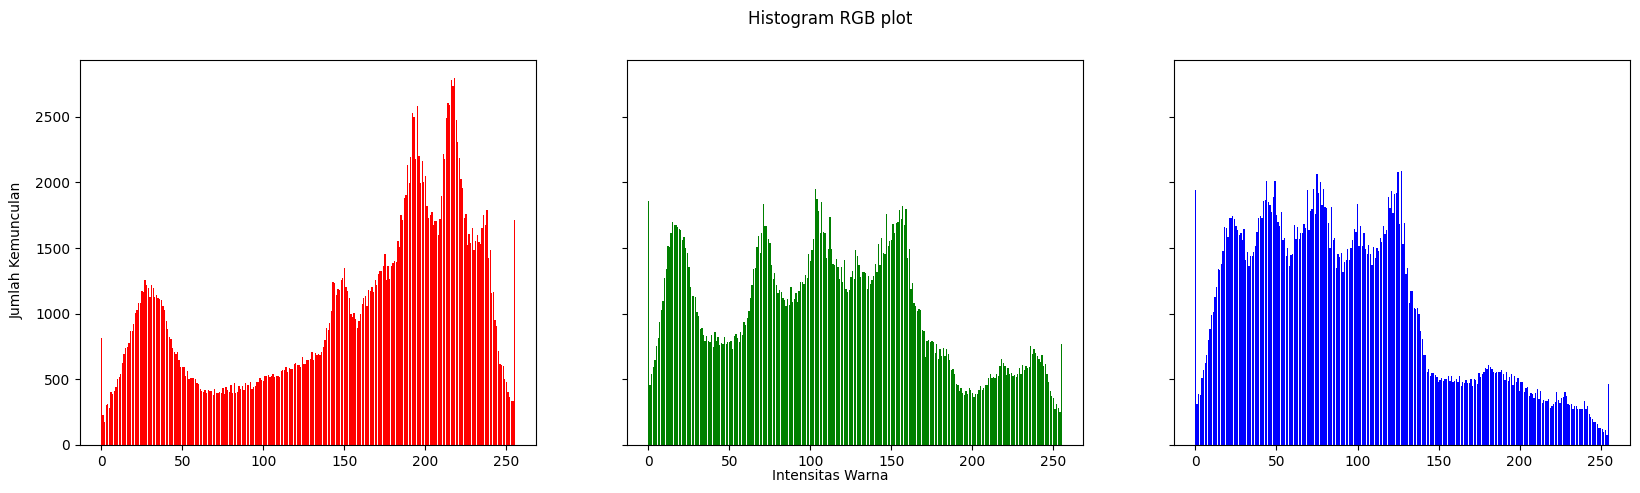

In [22]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y] [x] [0]] += 1
    green[img[y] [x] [1]] += 1
    blue[img[y] [x] [2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

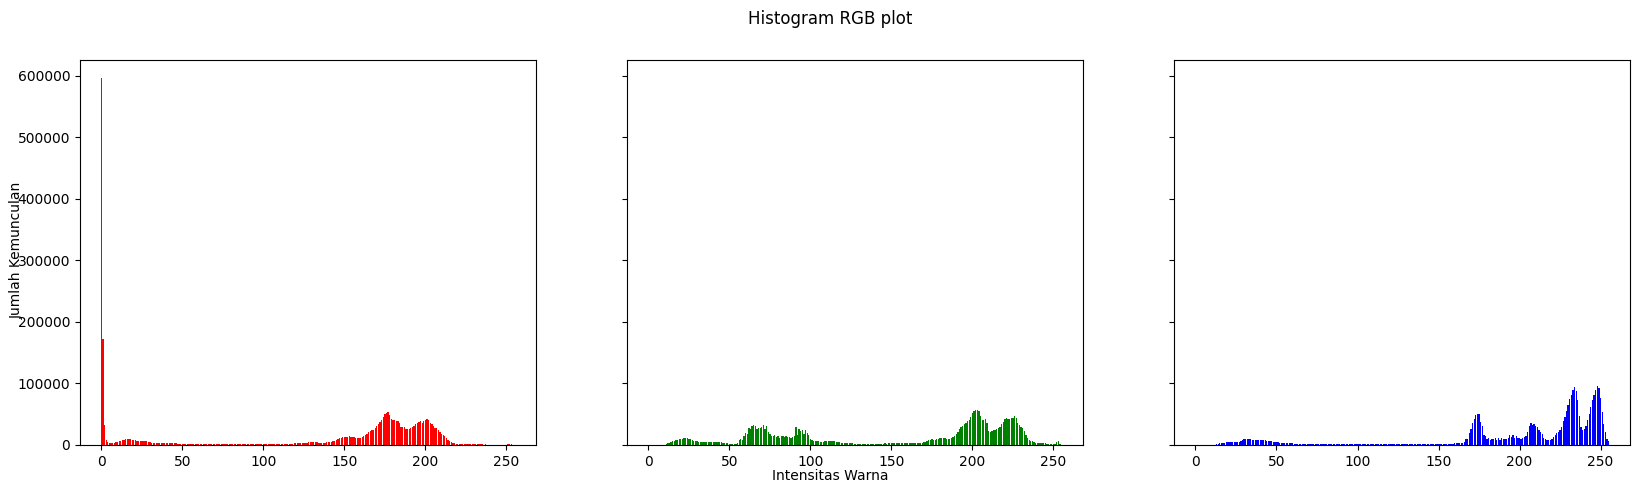

In [27]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y] [x] [0]] += 1
    green[img[y] [x] [1]] += 1
    blue[img[y] [x] [2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## **PERTANYAAN PRAKTIKUM E1**

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

## **Lena**

In [35]:
# Histogram manual
def histogram_manual(img):

    height, width, depth = np.shape(img)

    red = [0] * 256
    green = [0] * 256
    blue = [0] * 256

    for y in range(0, height):
        for x in range(0, width):

            red[img[y][x][0]] += 1
            green[img[y][x][1]] += 1
            blue[img[y][x][2]] += 1

    return np.array(red), np.array(green), np.array(blue)

In [36]:
# Histogram Numpy
def histogram_numpy(img):

    red, _ = np.histogram(
        img[:, :, 0],
        bins=256,
        range=(0, 256)
    )

    green, _ = np.histogram(
        img[:, :, 1],
        bins=256,
        range=(0, 256)
    )

    blue, _ = np.histogram(
        img[:, :, 2],
        bins=256,
        range=(0, 256)
    )

    return red, green, blue

In [37]:
# Histogram cv.calcHist()

def histogram_opencv(img):

    red = cv.calcHist(
        [img],
        [0],
        None,
        [256],
        [0, 256]
    ).flatten()

    green = cv.calcHist(
        [img],
        [1],
        None,
        [256],
        [0, 256]
    ).flatten()

    blue = cv.calcHist(
        [img],
        [2],
        None,
        [256],
        [0, 256]
    ).flatten()

    return red, green, blue

=== Selisih Histogram Lena ===
Red   : Manual vs NumPy  = 0
Red   : Manual vs OpenCV = 0
Green : Manual vs NumPy  = 0
Green : Manual vs OpenCV = 0
Blue  : Manual vs NumPy  = 0
Blue  : Manual vs OpenCV = 0


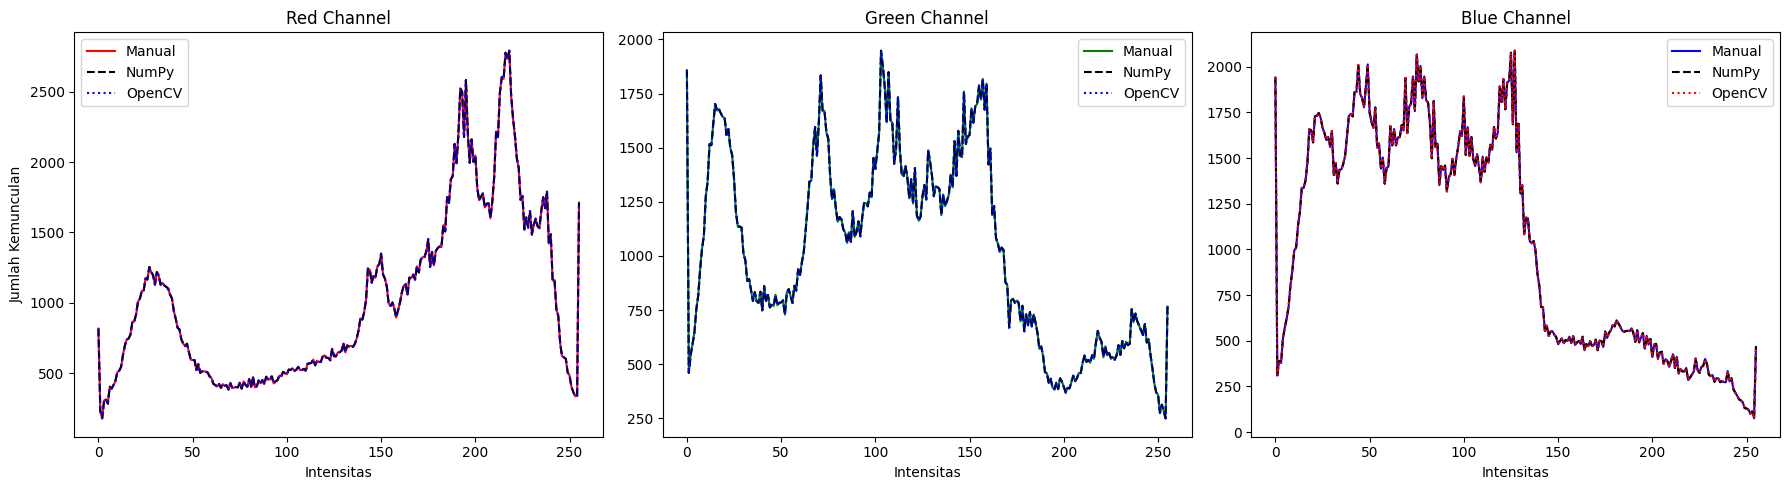

In [38]:
# Perbandingan ketiga histogram
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

  # def Histogram manual
manual_red, manual_green, manual_blue = histogram_manual(img)

  # def Histogram NumPy
numpy_red, numpy_green, numpy_blue = histogram_numpy(img)

  # def Histogram OpenCV
opencv_red, opencv_green, opencv_blue = histogram_opencv(img)

# Selisih Maksimum channel

# Selisih maksimum channel Red
diff_red_numpy = np.max(
    np.abs(manual_red.astype(np.int64) -
           numpy_red.astype(np.int64))
)

diff_red_opencv = np.max(
    np.abs(manual_red.astype(np.int64) -
           opencv_red.astype(np.int64))
)

# Selisih maksimum channel Green
diff_green_numpy = np.max(
    np.abs(manual_green.astype(np.int64) -
           numpy_green.astype(np.int64))
)

diff_green_opencv = np.max(
    np.abs(manual_green.astype(np.int64) -
           opencv_green.astype(np.int64))
)

# Selisih maksimum channel Blue
diff_blue_numpy = np.max(
    np.abs(manual_blue.astype(np.int64) -
           numpy_blue.astype(np.int64))
)

diff_blue_opencv = np.max(
    np.abs(manual_blue.astype(np.int64) -
           opencv_blue.astype(np.int64))
)

print("=== Selisih Histogram Lena ===")

print("Red   : Manual vs NumPy  =", diff_red_numpy)
print("Red   : Manual vs OpenCV =", diff_red_opencv)

print("Green : Manual vs NumPy  =", diff_green_numpy)
print("Green : Manual vs OpenCV =", diff_green_opencv)

print("Blue  : Manual vs NumPy  =", diff_blue_numpy)
print("Blue  : Manual vs OpenCV =", diff_blue_opencv)

# Pembuktian Histogram

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(names, manual_red, color='red', label='Manual')
axs[0].plot(names, numpy_red, '--', color='black', label='NumPy')
axs[0].plot(names, opencv_red, ':', color='blue', label='OpenCV')
axs[0].set_title('Red Channel')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].legend()

axs[1].plot(names, manual_green, color='green', label='Manual')
axs[1].plot(names, numpy_green, '--', color='black', label='NumPy')
axs[1].plot(names, opencv_green, ':', color='blue', label='OpenCV')
axs[1].set_title('Green Channel')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

axs[2].plot(names, manual_blue, color='blue', label='Manual')
axs[2].plot(names, numpy_blue, '--', color='black', label='NumPy')
axs[2].plot(names, opencv_blue, ':', color='red', label='OpenCV')
axs[2].set_title('Blue Channel')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

plt.tight_layout()
plt.show()

## **KTM**

=== Selisih Histogram KTM1b ===
Red   : Manual vs NumPy  = 0
Red   : Manual vs OpenCV = 0
Green : Manual vs NumPy  = 0
Green : Manual vs OpenCV = 0
Blue  : Manual vs NumPy  = 0
Blue  : Manual vs OpenCV = 0


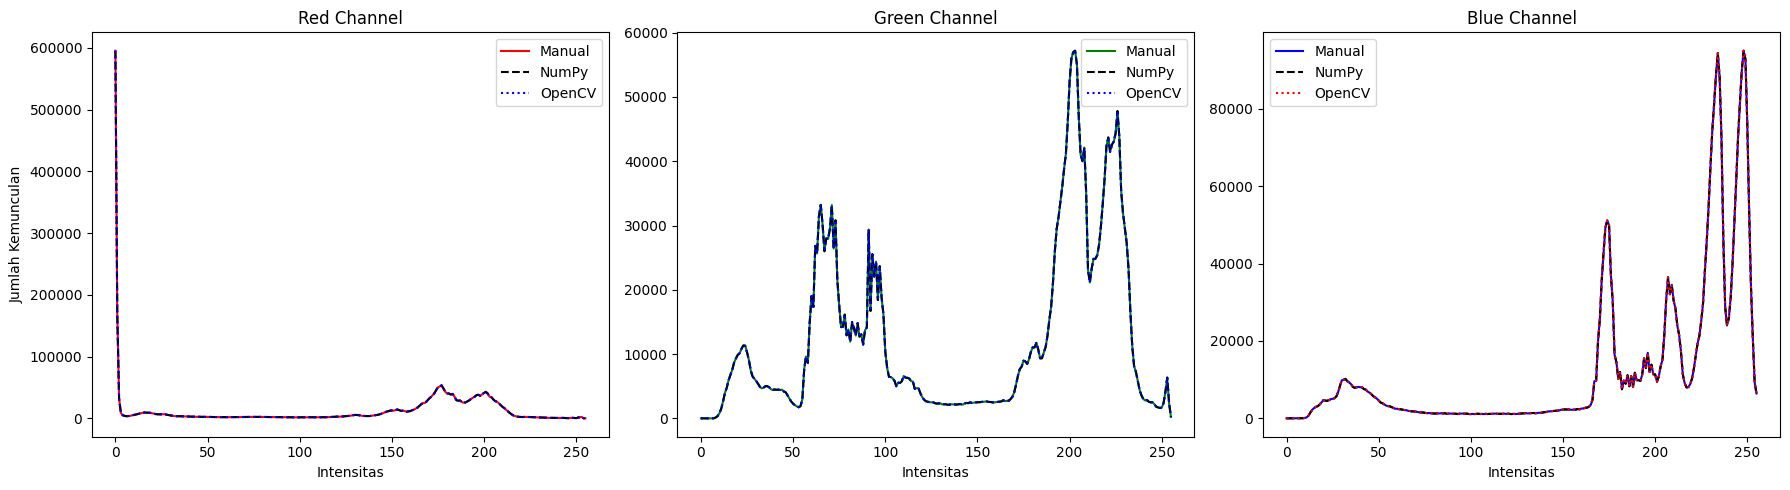

In [43]:
img = cv.imread(BASE + '/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Histogram manual
manual_red, manual_green, manual_blue = histogram_manual(img)
# Histogram numpy
numpy_red, numpy_green, numpy_blue = histogram_numpy(img)
# Histogram openCV
opencv_red, opencv_green, opencv_blue = histogram_opencv(img)

diff_red_numpy = np.max(
    np.abs(manual_red.astype(np.int64) -
           numpy_red.astype(np.int64))
)

diff_red_opencv = np.max(
    np.abs(manual_red.astype(np.int64) -
           opencv_red.astype(np.int64))
)

diff_green_numpy = np.max(
    np.abs(manual_green.astype(np.int64) -
           numpy_green.astype(np.int64))
)

diff_green_opencv = np.max(
    np.abs(manual_green.astype(np.int64) -
           opencv_green.astype(np.int64))
)

diff_blue_numpy = np.max(
    np.abs(manual_blue.astype(np.int64) -
           numpy_blue.astype(np.int64))
)

diff_blue_opencv = np.max(
    np.abs(manual_blue.astype(np.int64) -
           opencv_blue.astype(np.int64))
)

print("=== Selisih Histogram KTM1b ===")

print("Red   : Manual vs NumPy  =", diff_red_numpy)
print("Red   : Manual vs OpenCV =", diff_red_opencv)

print("Green : Manual vs NumPy  =", diff_green_numpy)
print("Green : Manual vs OpenCV =", diff_green_opencv)

print("Blue  : Manual vs NumPy  =", diff_blue_numpy)
print("Blue  : Manual vs OpenCV =", diff_blue_opencv)

# Pembuktian Histogram

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(names, manual_red, color='red', label='Manual')
axs[0].plot(names, numpy_red, '--', color='black', label='NumPy')
axs[0].plot(names, opencv_red, ':', color='blue', label='OpenCV')
axs[0].set_title('Red Channel')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].legend()

axs[1].plot(names, manual_green, color='green', label='Manual')
axs[1].plot(names, numpy_green, '--', color='black', label='NumPy')
axs[1].plot(names, opencv_green, ':', color='blue', label='OpenCV')
axs[1].set_title('Green Channel')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

axs[2].plot(names, manual_blue, color='blue', label='Manual')
axs[2].plot(names, numpy_blue, '--', color='black', label='NumPy')
axs[2].plot(names, opencv_blue, ':', color='red', label='OpenCV')
axs[2].set_title('Blue Channel')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

plt.tight_layout()
plt.show()

2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

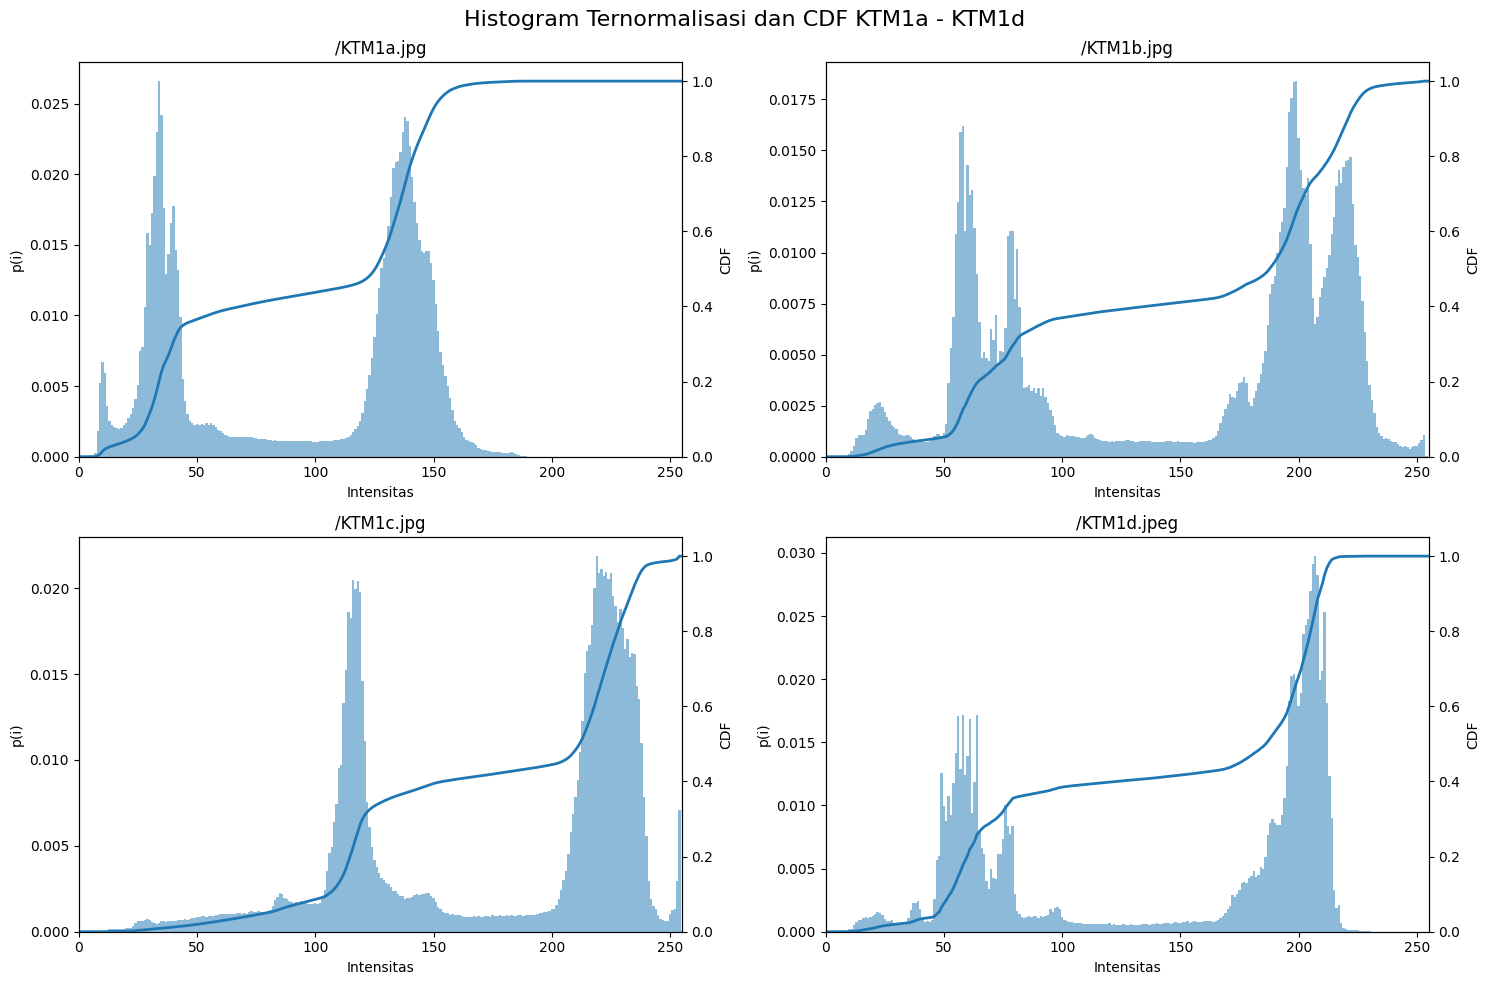

=== Rata-rata Intensitas ===
/KTM1a.jpg: 94.83
/KTM1b.jpg: 149.06
/KTM1c.jpg: 176.39
/KTM1d.jpeg: 143.22


In [46]:
files = [
    '/KTM1a.jpg',
    '/KTM1b.jpg',
    '/KTM1c.jpg',
    '/KTM1d.jpeg'
]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs = axs.ravel()

for i, file in enumerate(files):

    img = cv.imread(BASE + file)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    hist = cv.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256]
    ).flatten()

    # Histogram ternormalisasi
    probability = hist / hist.sum()

    # CDF
    cdf = np.cumsum(probability)

    intensity = np.arange(256)

    # Sumbu kiri untuk p(i)
    ax1 = axs[i]

    ax1.bar(
        intensity,
        probability,
        width=1,
        alpha=0.5,
        label='p(i)'
    )

    ax1.set_xlabel('Intensitas')
    ax1.set_ylabel('p(i)')
    ax1.set_xlim(0, 255)

    # Sumbu kanan untuk CDF
    ax2 = ax1.twinx()

    ax2.plot(
        intensity,
        cdf,
        linewidth=2,
        label='CDF'
    )

    ax2.set_ylabel('CDF')
    ax2.set_ylim(0, 1.05)

    ax1.set_title(file)

plt.suptitle(
    'Histogram Ternormalisasi dan CDF KTM1a - KTM1d',
    fontsize=16
)

plt.tight_layout()
plt.show()

print("=== Rata-rata Intensitas ===")

for file in files:

    img = cv.imread(path + file)

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    mean_intensity = np.mean(gray)

    print(f"{file}: {mean_intensity:.2f}")

Berdasarkan hasil histogram ternormalisasi dan kurva CDF, citra paling gelap adalah KTM1a.jpg dengan rata-rata intensitas sebesar 94,83, sedangkan citra paling terang adalah KTM1c.jpg dengan rata-rata intensitas sebesar 176,39. Pada KTM1a.jpg, kurva CDF mengalami kenaikan yang relatif lebih awal pada intensitas rendah karena sebagian besar piksel memiliki nilai intensitas yang relatif rendah. Hal tersebut sesuai dengan kondisi akuisisi KTM1a.jpg yang dilakukan di dalam ruangan gelap, sehingga jumlah cahaya yang diterima objek dan sensor kamera lebih sedikit.

Sebaliknya, pada KTM1c.jpg, kurva CDF relatif landai pada intensitas rendah dan mengalami kenaikan yang lebih tajam pada intensitas tinggi, terutama pada kisaran intensitas 220–250. Hal ini menunjukkan bahwa sebagian besar piksel pada citra tersebut memiliki intensitas yang tinggi. Kondisi tersebut sesuai dengan proses akuisisi KTM1c.jpg yang dilakukan menggunakan flash, sehingga objek memperoleh tambahan pencahayaan secara langsung. Dengan demikian, perbedaan bentuk kurva CDF antara KTM1a.jpg dan KTM1c.jpg menunjukkan bahwa kondisi pencahayaan saat akuisisi memengaruhi distribusi intensitas piksel. Pencahayaan yang lebih rendah cenderung menghasilkan distribusi intensitas yang lebih rendah dan CDF yang meningkat lebih awal, sedangkan pencahayaan yang lebih kuat menyebabkan distribusi intensitas bergeser ke nilai yang lebih tinggi sehingga kenaikan utama CDF terjadi pada intensitas yang lebih tinggi.


3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

In [47]:
img = cv.imread(
    BASE + '/KTM1b.jpg',
    cv.IMREAD_GRAYSCALE
)

# Histogram dengan PARAM['bins']
bins_param = PARAM['bins']

hist_param, bin_edges_param = np.histogram(
    img,
    bins=bins_param,
    range=(0, 256)
)

# Histogram dengan 256 bins
hist_256, bin_edges_256 = np.histogram(
    img,
    bins=256,
    range=(0, 256)
)

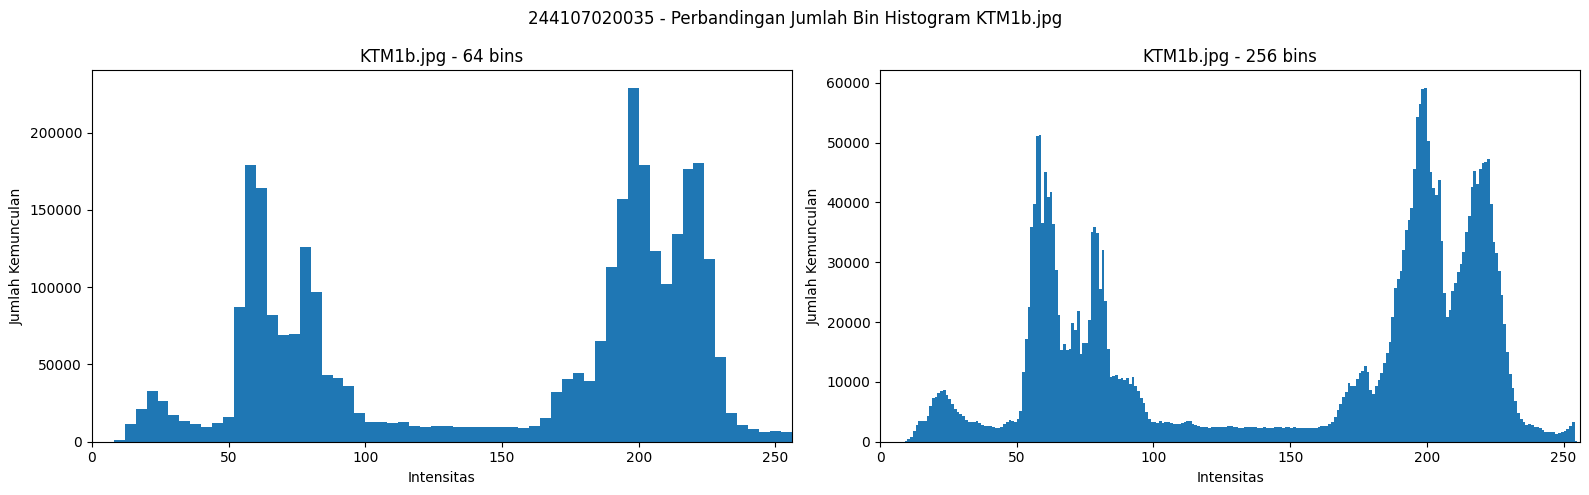

In [48]:
fig, axs = plt.subplots(
    1, 2,
    figsize=(16, 5)
)

fig.suptitle(
    NIM + ' - Perbandingan Jumlah Bin Histogram KTM1b.jpg'
)

# PARAM bins
axs[0].bar(
    bin_edges_param[:-1],
    hist_param,
    width=np.diff(bin_edges_param),
    align='edge'
)

axs[0].set_title(
    f'KTM1b.jpg - {bins_param} bins'
)

axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].set_xlim(0, 256)


# 256 bins
axs[1].bar(
    bin_edges_256[:-1],
    hist_256,
    width=np.diff(bin_edges_256),
    align='edge'
)

axs[1].set_title(
    'KTM1b.jpg - 256 bins'
)

axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Kemunculan')
axs[1].set_xlim(0, 256)

plt.tight_layout()
plt.show()

Histogram dengan 256 bin memberikan informasi distribusi intensitas yang jauh lebih mendetail karena setiap tingkat intensitas pada rentang 0–255 dapat direpresentasikan secara terpisah. Ketika jumlah bin dikurangi menjadi PARAM['bins'], beberapa nilai intensitas yang berdekatan akan digabungkan ke dalam satu kelompok. Akibatnya, detail perubahan frekuensi pada intensitas-intensitas yang berdekatan menjadi hilang dan bentuk histogram menjadi lebih kasar. Meskipun demikian, pola distribusi secara umum dan daerah intensitas yang dominan masih dapat diamati. Dengan demikian, semakin sedikit jumlah bin yang digunakan, semakin sedikit detail distribusi intensitas yang dapat diamati.


## **E-2 PERCOBAAN HISTOGRAM EQUALIZATION**

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

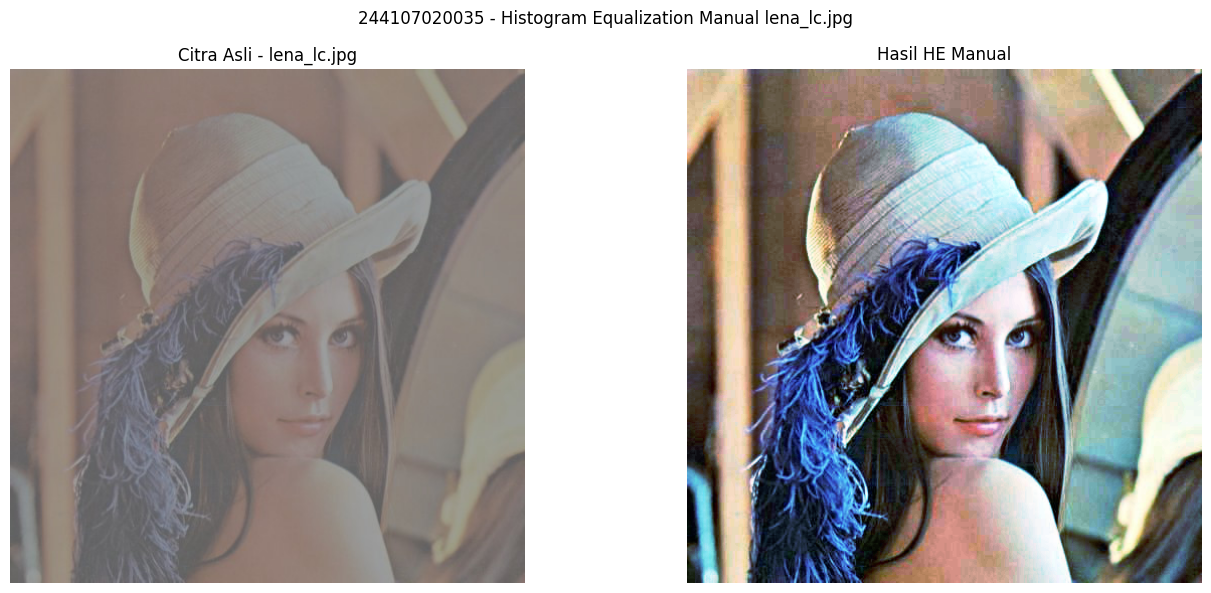

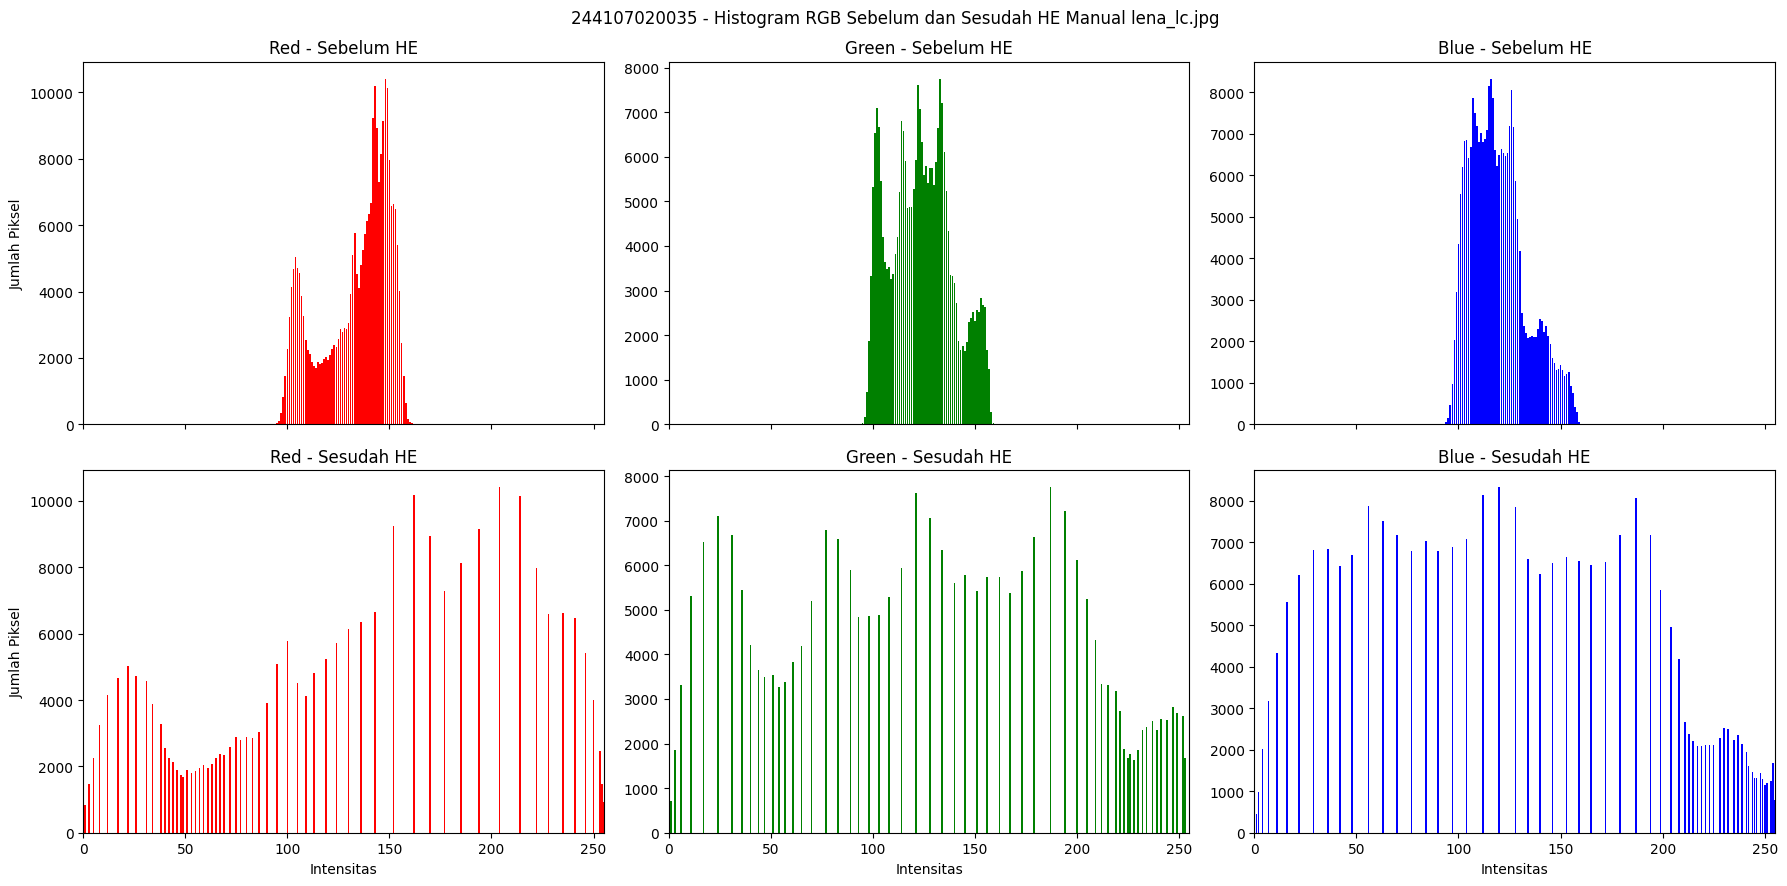

VALIDASI HISTOGRAM EQUALIZATION MANUAL
Shape citra asli      : (512, 512, 3)
Shape citra hasil HE  : (512, 512, 3)

Jumlah piksel Red     : 262144
Jumlah histogram Red  : 262144

Jumlah piksel Green   : 262144
Jumlah histogram Green: 262144

Jumlah piksel Blue    : 262144
Jumlah histogram Blue : 262144

CDF Red terakhir      : 1.0
CDF Green terakhir    : 1.0
CDF Blue terakhir     : 1.0


In [75]:
def histogram_manual_gray(img):
    """
    Menghitung histogram citra grayscale secara manual.
    Output: jumlah kemunculan untuk intensitas 0-255.
    """

    height, width = np.shape(img)

    hist = [0] * 256

    for y in range(height):
        for x in range(width):
            hist[img[y][x]] += 1

    return np.array(hist)


# ------------------------------------------------------------
# 2. Fungsi Histogram Equalization untuk 1 Channel
# ------------------------------------------------------------

def equalize_channel_manual(channel):
    """
    Melakukan Histogram Equalization manual
    pada satu channel grayscale.
    """

    L = 256

    # 1. Histogram
    hist = histogram_manual_gray(channel)

    # 2. Normalisasi histogram / probabilitas
    p = hist / channel.size

    # 3. Cumulative Distribution Function (CDF)
    cdf = np.cumsum(p)

    # 4. Transformasi intensitas
    transform = np.round(
        (L - 1) * cdf
    ).astype(np.uint8)

    # 5. Mapping setiap piksel
    hasil = transform[channel]

    return hasil, hist, p, cdf, transform


# ------------------------------------------------------------
# 3. Membaca lena_lc.jpg sebagai RGB
# ------------------------------------------------------------

img = cv.imread(
    CONTOH + '/lena_lc.jpg'
)

# OpenCV membaca gambar dalam format BGR,
# sehingga perlu diubah menjadi RGB
img = cv.cvtColor(
    img,
    cv.COLOR_BGR2RGB
)


# ------------------------------------------------------------
# 4. Pisahkan Channel RGB
# ------------------------------------------------------------

red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]


# ------------------------------------------------------------
# 5. Histogram Equalization Manual untuk
#    masing-masing channel
# ------------------------------------------------------------

red_he, hist_red, p_red, cdf_red, transform_red = \
    equalize_channel_manual(red)

green_he, hist_green, p_green, cdf_green, transform_green = \
    equalize_channel_manual(green)

blue_he, hist_blue, p_blue, cdf_blue, transform_blue = \
    equalize_channel_manual(blue)


# ------------------------------------------------------------
# 6. Gabungkan kembali channel RGB
# ------------------------------------------------------------

he_manual_lena = np.stack(
    [
        red_he,
        green_he,
        blue_he
    ],
    axis=2
)


# ------------------------------------------------------------
# 7. Histogram channel RGB setelah HE
# ------------------------------------------------------------

hist_he_red = histogram_manual_gray(red_he)
hist_he_green = histogram_manual_gray(green_he)
hist_he_blue = histogram_manual_gray(blue_he)


# ============================================================
# 8. TAMPILKAN CITRA SEBELUM DAN SESUDAH HE
# ============================================================

fig, axs = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

fig.suptitle(
    NIM + ' - Histogram Equalization Manual lena_lc.jpg'
)

# Citra asli
axs[0].imshow(img)
axs[0].set_title(
    'Citra Asli - lena_lc.jpg'
)
axs[0].axis('off')

# Citra hasil HE
axs[1].imshow(he_manual_lena)
axs[1].set_title(
    'Hasil HE Manual'
)
axs[1].axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# 9. HISTOGRAM RGB SEBELUM DAN SESUDAH HE
# ============================================================

fig, axs = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=True
)

fig.suptitle(
    NIM + ' - Histogram RGB Sebelum dan Sesudah HE Manual lena_lc.jpg'
)


# ------------------------------------------------------------
# BARIS 1 - SEBELUM HE
# ------------------------------------------------------------

axs[0, 0].bar(
    np.arange(256),
    hist_red,
    color='red'
)

axs[0, 0].set_title(
    'Red - Sebelum HE'
)

axs[0, 0].set_ylabel(
    'Jumlah Piksel'
)


axs[0, 1].bar(
    np.arange(256),
    hist_green,
    color='green'
)

axs[0, 1].set_title(
    'Green - Sebelum HE'
)


axs[0, 2].bar(
    np.arange(256),
    hist_blue,
    color='blue'
)

axs[0, 2].set_title(
    'Blue - Sebelum HE'
)


# ------------------------------------------------------------
# BARIS 2 - SESUDAH HE
# ------------------------------------------------------------

axs[1, 0].bar(
    np.arange(256),
    hist_he_red,
    color='red'
)

axs[1, 0].set_title(
    'Red - Sesudah HE'
)

axs[1, 0].set_xlabel(
    'Intensitas'
)

axs[1, 0].set_ylabel(
    'Jumlah Piksel'
)


axs[1, 1].bar(
    np.arange(256),
    hist_he_green,
    color='green'
)

axs[1, 1].set_title(
    'Green - Sesudah HE'
)

axs[1, 1].set_xlabel(
    'Intensitas'
)


axs[1, 2].bar(
    np.arange(256),
    hist_he_blue,
    color='blue'
)

axs[1, 2].set_title(
    'Blue - Sesudah HE'
)

axs[1, 2].set_xlabel(
    'Intensitas'
)


# ------------------------------------------------------------
# Pengaturan sumbu
# ------------------------------------------------------------

for ax in axs.flat:
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()


# ============================================================
# 10. VALIDASI HASIL
# ============================================================

print('==============================================')
print('VALIDASI HISTOGRAM EQUALIZATION MANUAL')
print('==============================================')

print('Shape citra asli      :', img.shape)
print('Shape citra hasil HE  :', he_manual_lena.shape)

print()
print('Jumlah piksel Red     :', red.size)
print('Jumlah histogram Red  :', hist_red.sum())

print()
print('Jumlah piksel Green   :', green.size)
print('Jumlah histogram Green:', hist_green.sum())

print()
print('Jumlah piksel Blue    :', blue.size)
print('Jumlah histogram Blue :', hist_blue.sum())

print()
print('CDF Red terakhir      :', cdf_red[-1])
print('CDF Green terakhir    :', cdf_green[-1])
print('CDF Blue terakhir     :', cdf_blue[-1])

In [64]:
# ============================================================
# E-2 - HISTOGRAM EQUALIZATION MANUAL
# Khusus citra grayscale
# ============================================================

def histogram_manual_gray(img):
    """
    Menghitung histogram citra grayscale secara manual.
    """

    height, width = np.shape(img)

    hist = [0] * 256

    for y in range(height):
        for x in range(width):
            hist[img[y][x]] += 1

    return np.array(hist)


def histogram_equalization_manual(gray):
    """
    Histogram Equalization manual.
    """

    L = 256

    # 1. Histogram grayscale
    hist = histogram_manual_gray(gray)

    # 2. Normalisasi histogram
    p = hist / gray.size

    # 3. CDF
    cdf = np.cumsum(p)

    # 4. Transformasi intensitas
    transform = np.round(
        (L - 1) * cdf
    ).astype(np.uint8)

    # 5. Mapping intensitas
    hasil = transform[gray]

    return hasil, hist, p, cdf, transform

In [74]:
img = cv.imread(CONTOH + '/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

he_manual_lena, hist_lena, p_lena, cdf_lena, transform_lena = \
    histogram_equalization_manual(img)

fig, axs = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

fig.suptitle(
    NIM + ' - Histogram Equalization Manual lena_lc.jpg'
)

axs[0].imshow(
    img,
    cmap='gray',
    vmin=0,
    vmax=255
)

axs[0].set_title('Citra Asli - lena_lc.jpg')
axs[0].axis('off')


axs[1].imshow(
    he_manual_lena,
    cmap='gray',
    vmin=0,
    vmax=255
)

axs[1].set_title('Hasil HE Manual')
axs[1].axis('off')

plt.tight_layout()
plt.show()

hist_he_lena = histogram_manual_gray(he_manual_lena)

fig, axs = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

fig.suptitle(
    NIM + ' - Histogram Sebelum dan Sesudah HE Manual lena_lc.jpg'
)

axs[0].bar(
    np.arange(256),
    hist_lena
)

axs[0].set_title('Histogram Sebelum HE')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Piksel')
axs[0].set_xlim(0, 255)


axs[1].bar(
    np.arange(256),
    hist_he_lena
)

axs[1].set_title('Histogram Sesudah HE')
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Piksel')
axs[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

ValueError: too many values to unpack (expected 2)